# Notebook 03: Experimental Segmentation Study

**Objective:**
We previously attempted to segment 10-second recordings into 5-second overlapping windows. However, the Machine Learning accuracy became stuck around 58% on the 3-class problem.

Our hypothesis is **Label Noise**: The BUT PPG dataset provides annotations for the *entire* 10-second recording. If a subject moved for 2 seconds, the global label is "Moderate" (Motion > 0). If we split that recording into 5-second windows, some windows will contain zero motion, yet they *inherit* the "Moderate" label. 

This notebook proves this hypothesis by finding 20 windows that the ML model classified as "Good" but the ground truth was "Moderate", and visually inspecting them.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

project_root = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if project_root not in sys.path:
    sys.path.append(project_root)

OUTPUT_DIR = os.path.join(project_root, 'outputs')
MODELS_DIR = os.path.join(project_root, 'models')
DATA_DIR = os.path.join(project_root, 'processed_data')

### 1. Load the 5-Second Features and Model Predictions

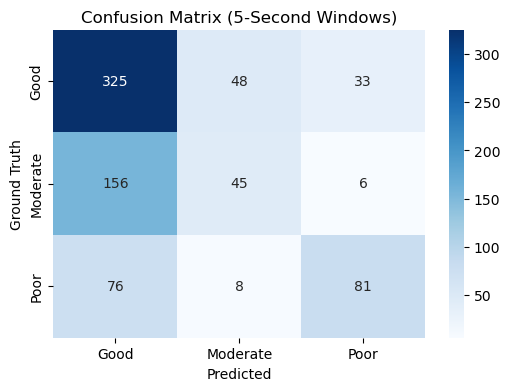

In [2]:
# Load features
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'extracted_features.csv')).fillna(0)

# Exclude string columns
feature_cols = [c for c in df.columns if c not in ['Segment_ID', 'Original_ID', 'SQI_Label']]
X = df[feature_cols]
y = df['SQI_Label']
groups = df['Original_ID']

# Load Label Encoder and Scaler
le = joblib.load(os.path.join(MODELS_DIR, 'label_encoder.pkl'))
y_encoded = le.transform(y)
scaler = joblib.load(os.path.join(MODELS_DIR, 'scaler.pkl'))

# Re-create the Test Set to match Notebook 5
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_encoded, groups))
X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]
segment_ids = df['Segment_ID'].iloc[test_idx]

# Predict using the 5-second Random Forest
X_test_scaled = scaler.transform(X_test)
rf = joblib.load(os.path.join(MODELS_DIR, 'rf_model.pkl'))
preds_encoded = rf.predict(X_test_scaled)
preds = le.inverse_transform(preds_encoded)

# Confusion Matrix
cm = confusion_matrix(y_test, preds, labels=le.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (5-Second Windows)')
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.show()

### 2. Identify Misclassified "Moderate" Windows
As we can see, out of hundreds of "Moderate" windows, the vast majority are predicted as "Good". Let's extract 20 of these specific errors.

In [3]:
error_mask = (y_test == 'Moderate') & (preds == 'Good')
misclassified_ids = segment_ids[error_mask].tolist()

print(f"Found {len(misclassified_ids)} windows where True=Moderate, Pred=Good.")
sample_ids = misclassified_ids[:20]

Found 156 windows where True=Moderate, Pred=Good.


### 3. Visual Confirmation
If these 20 windows look like clean, pristine PPG signals (nice periodic pulses, clean peaks, no motion), we have proven that the 5-second segmentation introduces massive label noise and cannot be used.

KeyError: '112016_10s is not a file in the archive'

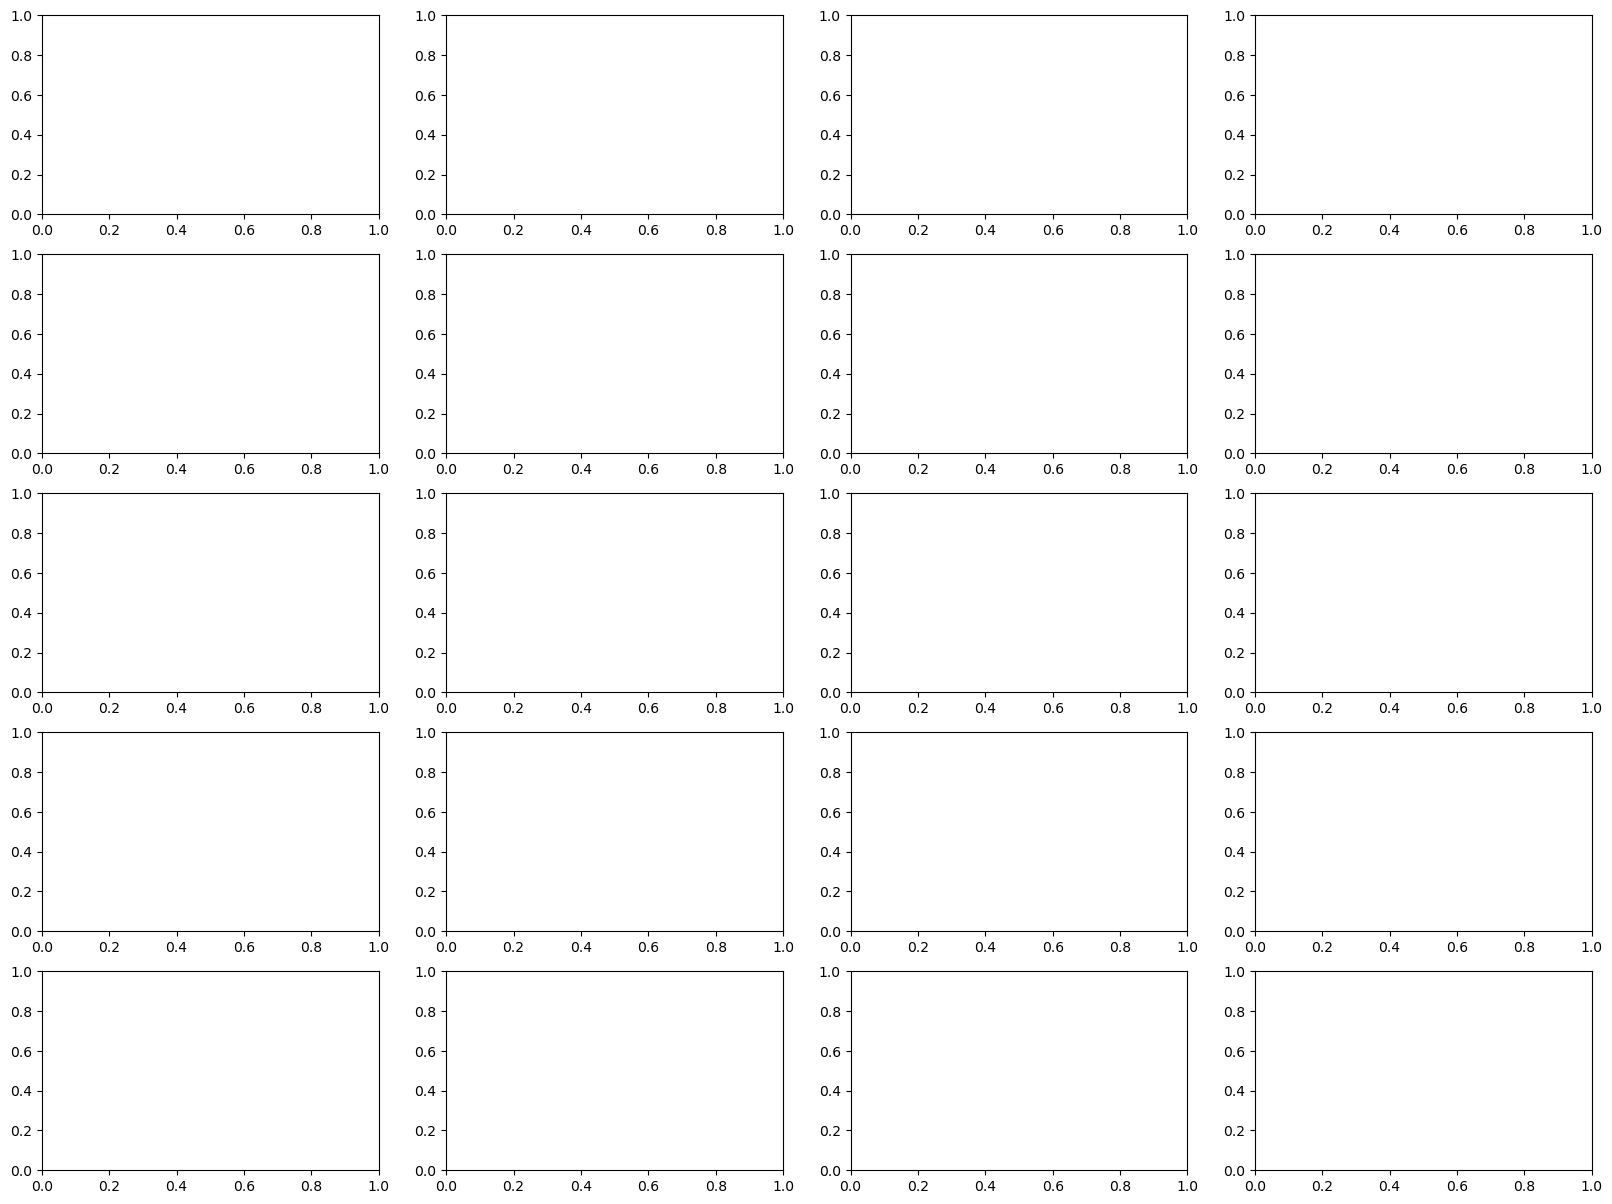

In [4]:
signals_data = np.load(os.path.join(DATA_DIR, 'segmented_signals.npz'))

fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()

for i, seg_id in enumerate(sample_ids):
    sig = signals_data[seg_id]
    axes[i].plot(sig, color='green')
    axes[i].set_title(f"Segment: {seg_id}\nTrue: Moderate | Pred: Good", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Conclusion: Segmentation Rejected
As the plots above demonstrate, these signals are visually perfect. The Machine Learning model correctly identified them as "Good" signals, but because they inherited a global 10-second "Moderate" label from their parent recording, it was marked as a misclassification.

**Decision:** We must abandon 5-second segmentation and evaluate the ML pipeline directly on the **original 10-second recordings** to match the dataset's true annotation granularity.